# Model Evaluation

### Import Libraries

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

### Load Best Model

In [2]:
# code

model = load_model(
    "../models/best_custom_cnn.keras"
)

### Recreate Generators in Model Evaluation Notebook

In [3]:
# code

# Dataset Paths

test_dir = "../data/test"

# Image Parameters

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 20

# Test Generator

val_test_datagen = ImageDataGenerator(

    rescale=1./255
)

# Create Test Loader

test_generator = val_test_datagen.flow_from_directory(

    test_dir,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 401 images belonging to 2 classes.


### Evaluate Model on Test Data

In [4]:
# code

test_loss, test_accuracy = model.evaluate(
    test_generator
)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.8803 - loss: 0.3093
Test Loss: 0.3092673420906067
Test Accuracy: 0.8802992701530457


### Generate Predictions

In [5]:
# code

predictions = model.predict(
    test_generator
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step


#### Convert Probabilities to Class Labels

In [6]:
# code

y_pred = np.argmax(
    predictions,
    axis=1
)

#### Get True Labels

In [7]:
# code

y_true = test_generator.classes

### Confusion Matrix

In [8]:
# One of the most important evaluation tools.

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[180  33]
 [ 15 173]]


### Plot Confusion Matrix

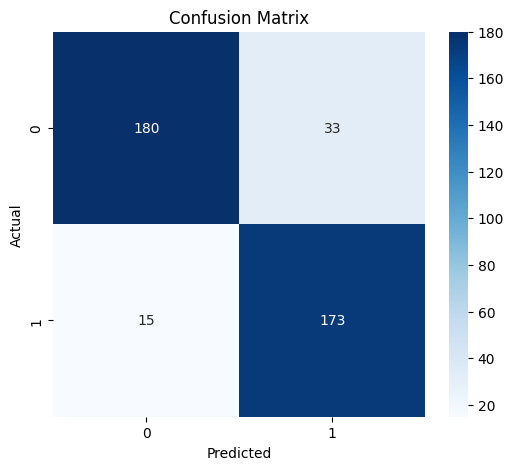

In [9]:
# code

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Classification Report

In [10]:
# Performance metrics

class_names = list(
    test_generator.class_indices.keys()
)

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

        bird       0.92      0.85      0.88       213
       drone       0.84      0.92      0.88       188

    accuracy                           0.88       401
   macro avg       0.88      0.88      0.88       401
weighted avg       0.88      0.88      0.88       401



### Calculate Accuracy Manually

In [11]:
# code

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8802992518703242


### Visualize Predictions

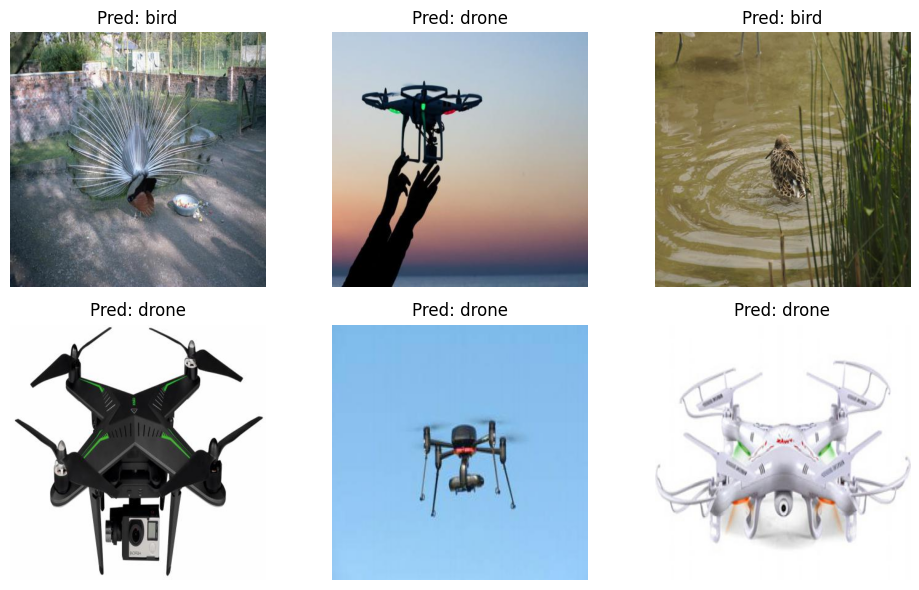

In [12]:
# code

import random

plt.figure(figsize=(10, 6))

for i in range(6):

    index = random.randint(
        0,
        len(test_generator.filepaths) - 1
    )

    img_path = test_generator.filepaths[index]

    img = plt.imread(img_path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(img)

    plt.title(
        f"Pred: {class_names[y_pred[index]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

### Evaluation Results

In [13]:
import pandas as pd

df = pd.DataFrame(

    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

)

df.to_csv(
    "../results/result.csv"
)